In [84]:
!pip install nltk
!pip install pymorphy3
!pip install WordCloud
!pip install stop_words

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Удалить пунктуацию

In [86]:
pd.set_option('display.max_colwidth', 100)

data = pd.read_excel("/content/Разметка новостей (3).xlsx")



data = data.rename(columns = {'Header.1' : 'body_text'})
data.head()

,Id,Header,body_text,1 разметчик,2 разметчик,1. Существенное,1. Направление,2. Существенное,2. Направление
0,S_15,"События (действия), оказывающие, по мнению эмитента, существенное влияние на стоимость или котир...","СООБЩЕНИЕ об иных событиях (действиях), оказывающих, по мнению эмитента, существенное влияние на...",Михайленко Даниил,Горбачев Данил,1,1.0,1,1.0
1,S_16,Проведение заседания совета директоров (наблюдательного совета) и его повестка дня,СООБЩЕНИЕ о существенном факте\n«О проведении заседания Наблюдательного совета эмитента и его по...,Михайленко Даниил,Горбачев Данил,0,NaN,0,NaN
2,S_23,Досрочное частичное погашение облигаций,СООБЩЕНИЕ о существенном факте\n«О досрочном погашении облигаций эмитента»\n \n2.1. Идентификаци...,Сигаева Марина,Сидоров Павел,1,1.0,1,1.0
3,S_27,Досрочное частичное погашение облигаций,СООБЩЕНИЕ о существенном факте\n«О досрочном погашении облигаций эмитента»\n \n2.1. Идентификаци...,Никошин Денис,Горбачев Данил,0,NaN,0,NaN
4,S_30,Решения совета директоров (наблюдательного совета),"СООБЩЕНИЕ о существенном факте\n«Об отдельных решениях, принятых Наблюдательным советом эмитента...",Никошин Денис,Михайленко Даниил,0,NaN,0,NaN


### Токенизация

In [87]:
import re

def tokenise(s):
    # Убираем пробелы внутри чисел (например, 10 000 000 → 10000000)
    s = re.sub(r'(?<=\d) (?=\d)', '', s)

    # Заменяем все вещественные числа и проценты на маркеры
    s_with_marks = re.sub(r'\d+\.\d+%', lambda m: f'PERCENT{m.group(0)}__', s)
    s_with_marks = re.sub(r'\d+\.\d+', lambda m: f'FLOAT{m.group(0)}__', s_with_marks)

    # Группируем "руб." с предыдущим числом или словом
    s_with_marks = re.sub(r'(\S+) (руб\.)', r'\1\2', s_with_marks)

    # Убираем запятые, если они не являются частью числа (например, "1,234" должно остаться)
    s_with_marks = re.sub(r'(?<!\d),(?!\d)', '', s_with_marks)

    # Разделяем строку по пробелам, знакам препинания (кроме точек в числах и процентах)
    parts = re.split(r'[^a-zA-Zа-яА-Я0-9.%]+', s_with_marks)

    # Убираем одинокие знаки препинания и точки в конце слов (если они не в числе/проценте)
    result = [
        re.sub(r'\.(?=$|[^0-9])', '', part.replace('FLOAT', '').replace('PERCENT', ''))
        for part in parts
        if part and not re.fullmatch(r'[.,%]+', part)
    ]

    # Восстанавливаем "не " перед словами
    cleaned_result = []
    i = 0
    while i < len(result):
        if result[i] == "не" and i + 1 < len(result):
            cleaned_result.append("не " + result[i + 1])
            i += 2  # Пропускаем следующее слово, так как уже объединили
        else:
            cleaned_result.append(result[i])
            i += 1

    # Фильтруем слова:
    final_result = [
        word for word in cleaned_result
        if "ru" not in word.lower()                 # Убираем слова с "ru"
        and "www" not in word.lower()               # Убираем слова с "www"
        and not re.search(r'\d+b', word.lower())    # Убираем облигации (например, "10b")
        and not re.search(r'\d+[a-zA-Z]+', word)    # Убираем смешанные слова (например, "4b0215401481b001p")
    ]

    return final_result

# Пример использования
input_string = "Привет, 123.45 мир! Это не правда, 50% скидка. Сумма 1 000 руб. Сайт www.example.com, облигация 5b и код 4b0215401481b001p."
result = tokenise(input_string)
print(result)

['Привет', '123.45', 'мир', 'Это', 'не правда', '50%', 'скидка', 'Сумма', '1000руб', 'Сайт', 'облигация', 'и', 'код']


In [88]:
data['body_text_tokenised'] = data['body_text'].apply(lambda x: tokenise(x.lower()))
data.head()
print(data['body_text_tokenised'].iloc[98])


['сообщение', 'о', 'существенном', 'факте', 'об', 'иных', 'событиях', 'действиях', 'оказывающих', 'по', 'мнению', 'эмитента', 'существенное', 'влияние', 'на', 'стоимость', 'или', 'котировки', 'его', 'ценных', 'бумаг', '2.1', 'краткое', 'описание', 'события', 'действия', 'наступление', 'совершение', 'которого', 'по', 'мнению', 'эмитента', 'оказывает', 'влияние', 'на', 'стоимость', 'или', 'котировки', 'его', 'ценных', 'бумаг', 'о', 'величине', 'дополнительного', 'дохода', 'по', 'биржевым', 'облигациям', 'серии', 'иос', 'bsk', 'fix', 'mem', '001р', '2.2', 'в', 'случае', 'если', 'событие', 'действие', 'имеет', 'отношение', 'к', 'третьему', 'лицу', 'полное', 'фирменное', 'наименование', 'для', 'коммерческой', 'организации', 'или', 'наименование', 'для', 'некоммерческих', 'организаций', 'место', 'нахождения', 'идентификационный', 'номер', 'налогоплательщика', 'инн', 'при', 'наличии', 'основной', 'государственный', 'регистрационный', 'номер', 'огрн', 'при', 'наличии', 'или', 'фамилия', 'имя',

In [89]:
print(data['body_text_tokenised'].iloc[98])

['сообщение', 'о', 'существенном', 'факте', 'об', 'иных', 'событиях', 'действиях', 'оказывающих', 'по', 'мнению', 'эмитента', 'существенное', 'влияние', 'на', 'стоимость', 'или', 'котировки', 'его', 'ценных', 'бумаг', '2.1', 'краткое', 'описание', 'события', 'действия', 'наступление', 'совершение', 'которого', 'по', 'мнению', 'эмитента', 'оказывает', 'влияние', 'на', 'стоимость', 'или', 'котировки', 'его', 'ценных', 'бумаг', 'о', 'величине', 'дополнительного', 'дохода', 'по', 'биржевым', 'облигациям', 'серии', 'иос', 'bsk', 'fix', 'mem', '001р', '2.2', 'в', 'случае', 'если', 'событие', 'действие', 'имеет', 'отношение', 'к', 'третьему', 'лицу', 'полное', 'фирменное', 'наименование', 'для', 'коммерческой', 'организации', 'или', 'наименование', 'для', 'некоммерческих', 'организаций', 'место', 'нахождения', 'идентификационный', 'номер', 'налогоплательщика', 'инн', 'при', 'наличии', 'основной', 'государственный', 'регистрационный', 'номер', 'огрн', 'при', 'наличии', 'или', 'фамилия', 'имя',

### Lemmatizing

In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

def lemmatizing(tokenized_text):
    text = [morph.parse(word)[0].normal_form for word in tokenized_text]
    return text

data['body_text_lemmatized'] = data['body_text_tokenised'].apply(lambda x: lemmatizing(x))
data.head()

In [95]:
data['body_text_lemmatized'].iloc[98]

['сообщение',
 'о',
 'существенный',
 'факт',
 'о',
 'иной',
 'событие',
 'действие',
 'оказывать',
 'по',
 'мнение',
 'эмитент',
 'существенный',
 'влияние',
 'на',
 'стоимость',
 'или',
 'котировка',
 'он',
 'ценный',
 'бумага',
 '2.1',
 'краткий',
 'описание',
 'событие',
 'действие',
 'наступление',
 'совершение',
 'который',
 'по',
 'мнение',
 'эмитент',
 'оказывать',
 'влияние',
 'на',
 'стоимость',
 'или',
 'котировка',
 'он',
 'ценный',
 'бумага',
 'о',
 'величина',
 'дополнительный',
 'доход',
 'по',
 'биржевой',
 'облигация',
 'серия',
 'иос',
 'bsk',
 'fix',
 'mem',
 '001р',
 '2.2',
 'в',
 'случай',
 'если',
 'событие',
 'действие',
 'иметь',
 'отношение',
 'к',
 'третий',
 'лицо',
 'полный',
 'фирменный',
 'наименование',
 'для',
 'коммерческий',
 'организация',
 'или',
 'наименование',
 'для',
 'некоммерческий',
 'организация',
 'место',
 'нахождение',
 'идентификационный',
 'номер',
 'налогоплательщик',
 'инна',
 'при',
 'наличие',
 'основной',
 'государственный',
 'регис

### Стоп слова

In [96]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stopword = nltk.corpus.stopwords.words('russian')

stopword_new = ['сообщение', 'иных', 'существенное', 'существенный', 'факт','событие', 'влияние', 'существенном', 'действие', 'факте', 'протокол',
               'орган', ',', 'выпуск', 'ru', 'номер', 'bsk', 'prt', 'далее', 'серия', 'b', 't', '4b02', 'prt', 'www', '401481в001p02e',
               '5y', 'категория', 'isin', 'http', '001р', 'mem', 'мнение', 'кворум', 'имелся','запятая',
               'пао', 'fix', 'федерация', 'должный', 'фирменный', 'страница', 'признак', 'указанный', 'иос', 'адрес', 'форма', 'инна', 'иной', 'г']

stopword.extend(stopword_new)
stopword.remove('не')


In [101]:
def remove_stopwords(tokenised_list):
    text = [word for word in tokenised_list if word not in stopword]
    return text

data['body_text_nostop'] = data['body_text_lemmatized'].apply(lambda x: remove_stopwords(x))
data.head()

,Id,Header,body_text,1 разметчик,2 разметчик,1. Существенное,1. Направление,2. Существенное,2. Направление,body_text_tokenised,body_text_lemmatized,body_text_nostop
0,S_15,"События (действия), оказывающие, по мнению эмитента, существенное влияние на стоимость или котир...","СООБЩЕНИЕ об иных событиях (действиях), оказывающих, по мнению эмитента, существенное влияние на...",Михайленко Даниил,Горбачев Данил,1,1.0,1,1.0,"[сообщение, об, иных, событиях, действиях, оказывающих, по, мнению, эмитента, существенное, влия...","[сообщение, о, иной, событие, действие, оказывать, по, мнение, эмитент, существенный, влияние, н...","[оказывать, эмитент, стоимость, котировка, ценный, бумага, сократить, результат, сбербанк, рпб, ..."
1,S_16,Проведение заседания совета директоров (наблюдательного совета) и его повестка дня,СООБЩЕНИЕ о существенном факте\n«О проведении заседания Наблюдательного совета эмитента и его по...,Михайленко Даниил,Горбачев Данил,0,NaN,0,NaN,"[сообщение, о, существенном, факте, о, проведении, заседания, наблюдательного, совета, эмитента,...","[сообщение, о, существенный, факт, о, проведение, заседание, наблюдательный, совет, эмитент, и, ...","[проведение, заседание, наблюдательный, совет, эмитент, повестка, день, 2.1, дата, принятие, пре..."
2,S_23,Досрочное частичное погашение облигаций,СООБЩЕНИЕ о существенном факте\n«О досрочном погашении облигаций эмитента»\n \n2.1. Идентификаци...,Сигаева Марина,Сидоров Павел,1,1.0,1,1.0,"[сообщение, о, существенном, факте, о, досрочном, погашении, облигаций, эмитента, 2.1, идентифик...","[сообщение, о, существенный, факт, о, досрочный, погашение, облигация, эмитент, 2.1, идентификац...","[досрочный, погашение, облигация, эмитент, 2.1, идентификационный, ценный, бумага, облигация, эм..."
3,S_27,Досрочное частичное погашение облигаций,СООБЩЕНИЕ о существенном факте\n«О досрочном погашении облигаций эмитента»\n \n2.1. Идентификаци...,Никошин Денис,Горбачев Данил,0,NaN,0,NaN,"[сообщение, о, существенном, факте, о, досрочном, погашении, облигаций, эмитента, 2.1, идентифик...","[сообщение, о, существенный, факт, о, досрочный, погашение, облигация, эмитент, 2.1, идентификац...","[досрочный, погашение, облигация, эмитент, 2.1, идентификационный, ценный, бумага, облигация, эм..."
4,S_30,Решения совета директоров (наблюдательного совета),"СООБЩЕНИЕ о существенном факте\n«Об отдельных решениях, принятых Наблюдательным советом эмитента...",Никошин Денис,Михайленко Даниил,0,NaN,0,NaN,"[сообщение, о, существенном, факте, об, отдельных, решениях, принятых, наблюдательным, советом, ...","[сообщение, о, существенный, факт, о, отдельный, решение, принять, наблюдательный, совет, эмитен...","[отдельный, решение, принять, наблюдательный, совет, эмитент, 2.1, сведение, заседание, наблюдат..."


### Векторизация

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

count_vect = CountVectorizer()
X_counts = count_vect.fit_transform(data['body_text_nostop'].apply(lambda x: ' '.join(x)))
X_counts.shape

In [105]:
count_vect.get_feature_names_out()

array(['00', '000', '0000', ..., 'японский', 'яркий', 'ёмкость'],
      dtype=object)

In [ ]:
X_counts_df = pd.DataFrame(X_counts.toarray())
X_counts_df

In [108]:
X_counts_df.columns = count_vect.get_feature_names_out()
X_counts_df

,00,000,0000,00000025,0001,0002,00024,000717,00077,001,...,язык,яковлев,ян,январь,яндекс,яндекседа,япония,японский,яркий,ёмкость
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
996,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### N-gram алгоритм

In [109]:
from sklearn.feature_extraction.text import CountVectorizer

In [110]:
ngram_vect = CountVectorizer(ngram_range=(2,2))
X_counts_n_gram = ngram_vect.fit_transform(data['body_text_nostop'].apply(lambda x: ' '.join(x)))

In [111]:
print(X_counts_n_gram.shape)

(1000, 29808)


In [112]:
X_counts_n_gram_df = pd.DataFrame(X_counts_n_gram.toarray())

In [113]:
X_counts_n_gram_df

,0,1,2,3,4,5,6,7,8,9,...,29798,29799,29800,29801,29802,29803,29804,29805,29806,29807
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Частота встречаемости

In [114]:
text = []
[text.extend(t) for t in data['body_text_nostop']]

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [115]:
len(text)

265755

In [116]:
from nltk.probability import FreqDist
fdist = FreqDist(text)

In [117]:
fdist.most_common(5)

[('ценный', 9901),
 ('бумага', 9898),
 ('эмитент', 8501),
 ('облигация', 8343),
 ('биржевой', 6178)]

In [118]:
for key in fdist:
    if 'эмитента,' in key:
        print(key, fdist[key])

<Axes: xlabel='Samples', ylabel='Counts'>

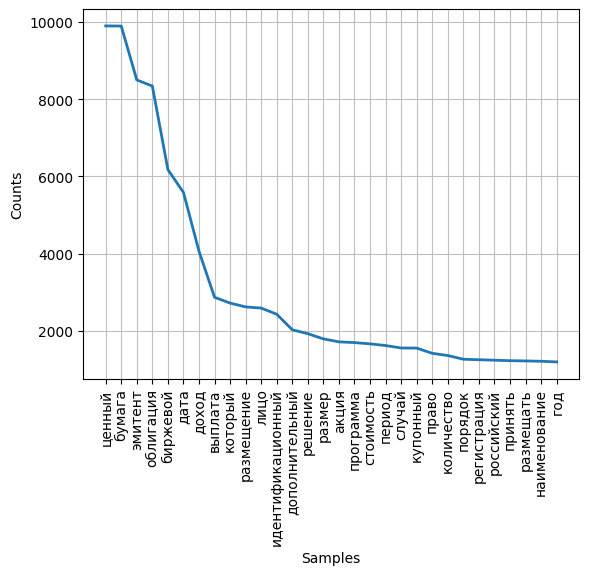

In [119]:
fdist.plot(30,cumulative=False)

### Облако слов

In [120]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline

In [121]:
# Функция для визуализации облака слов
def plot_cloud(wordcloud):
    # Устанавливаем размер картинки
    plt.figure(figsize=(40, 30))
    # Показать изображение
    plt.imshow(wordcloud)
    # Без подписей на осях
    plt.axis("off")

In [122]:
text_raw = " ".join(text)

In [123]:
wordcloud = WordCloud(width = 2000,
                      height = 1500,
                      random_state=1,
                      background_color='white',
                      colormap='Set2',
                      collocations=False,
                     stopwords=stopword).generate(text_raw)

In [124]:
print(wordcloud)

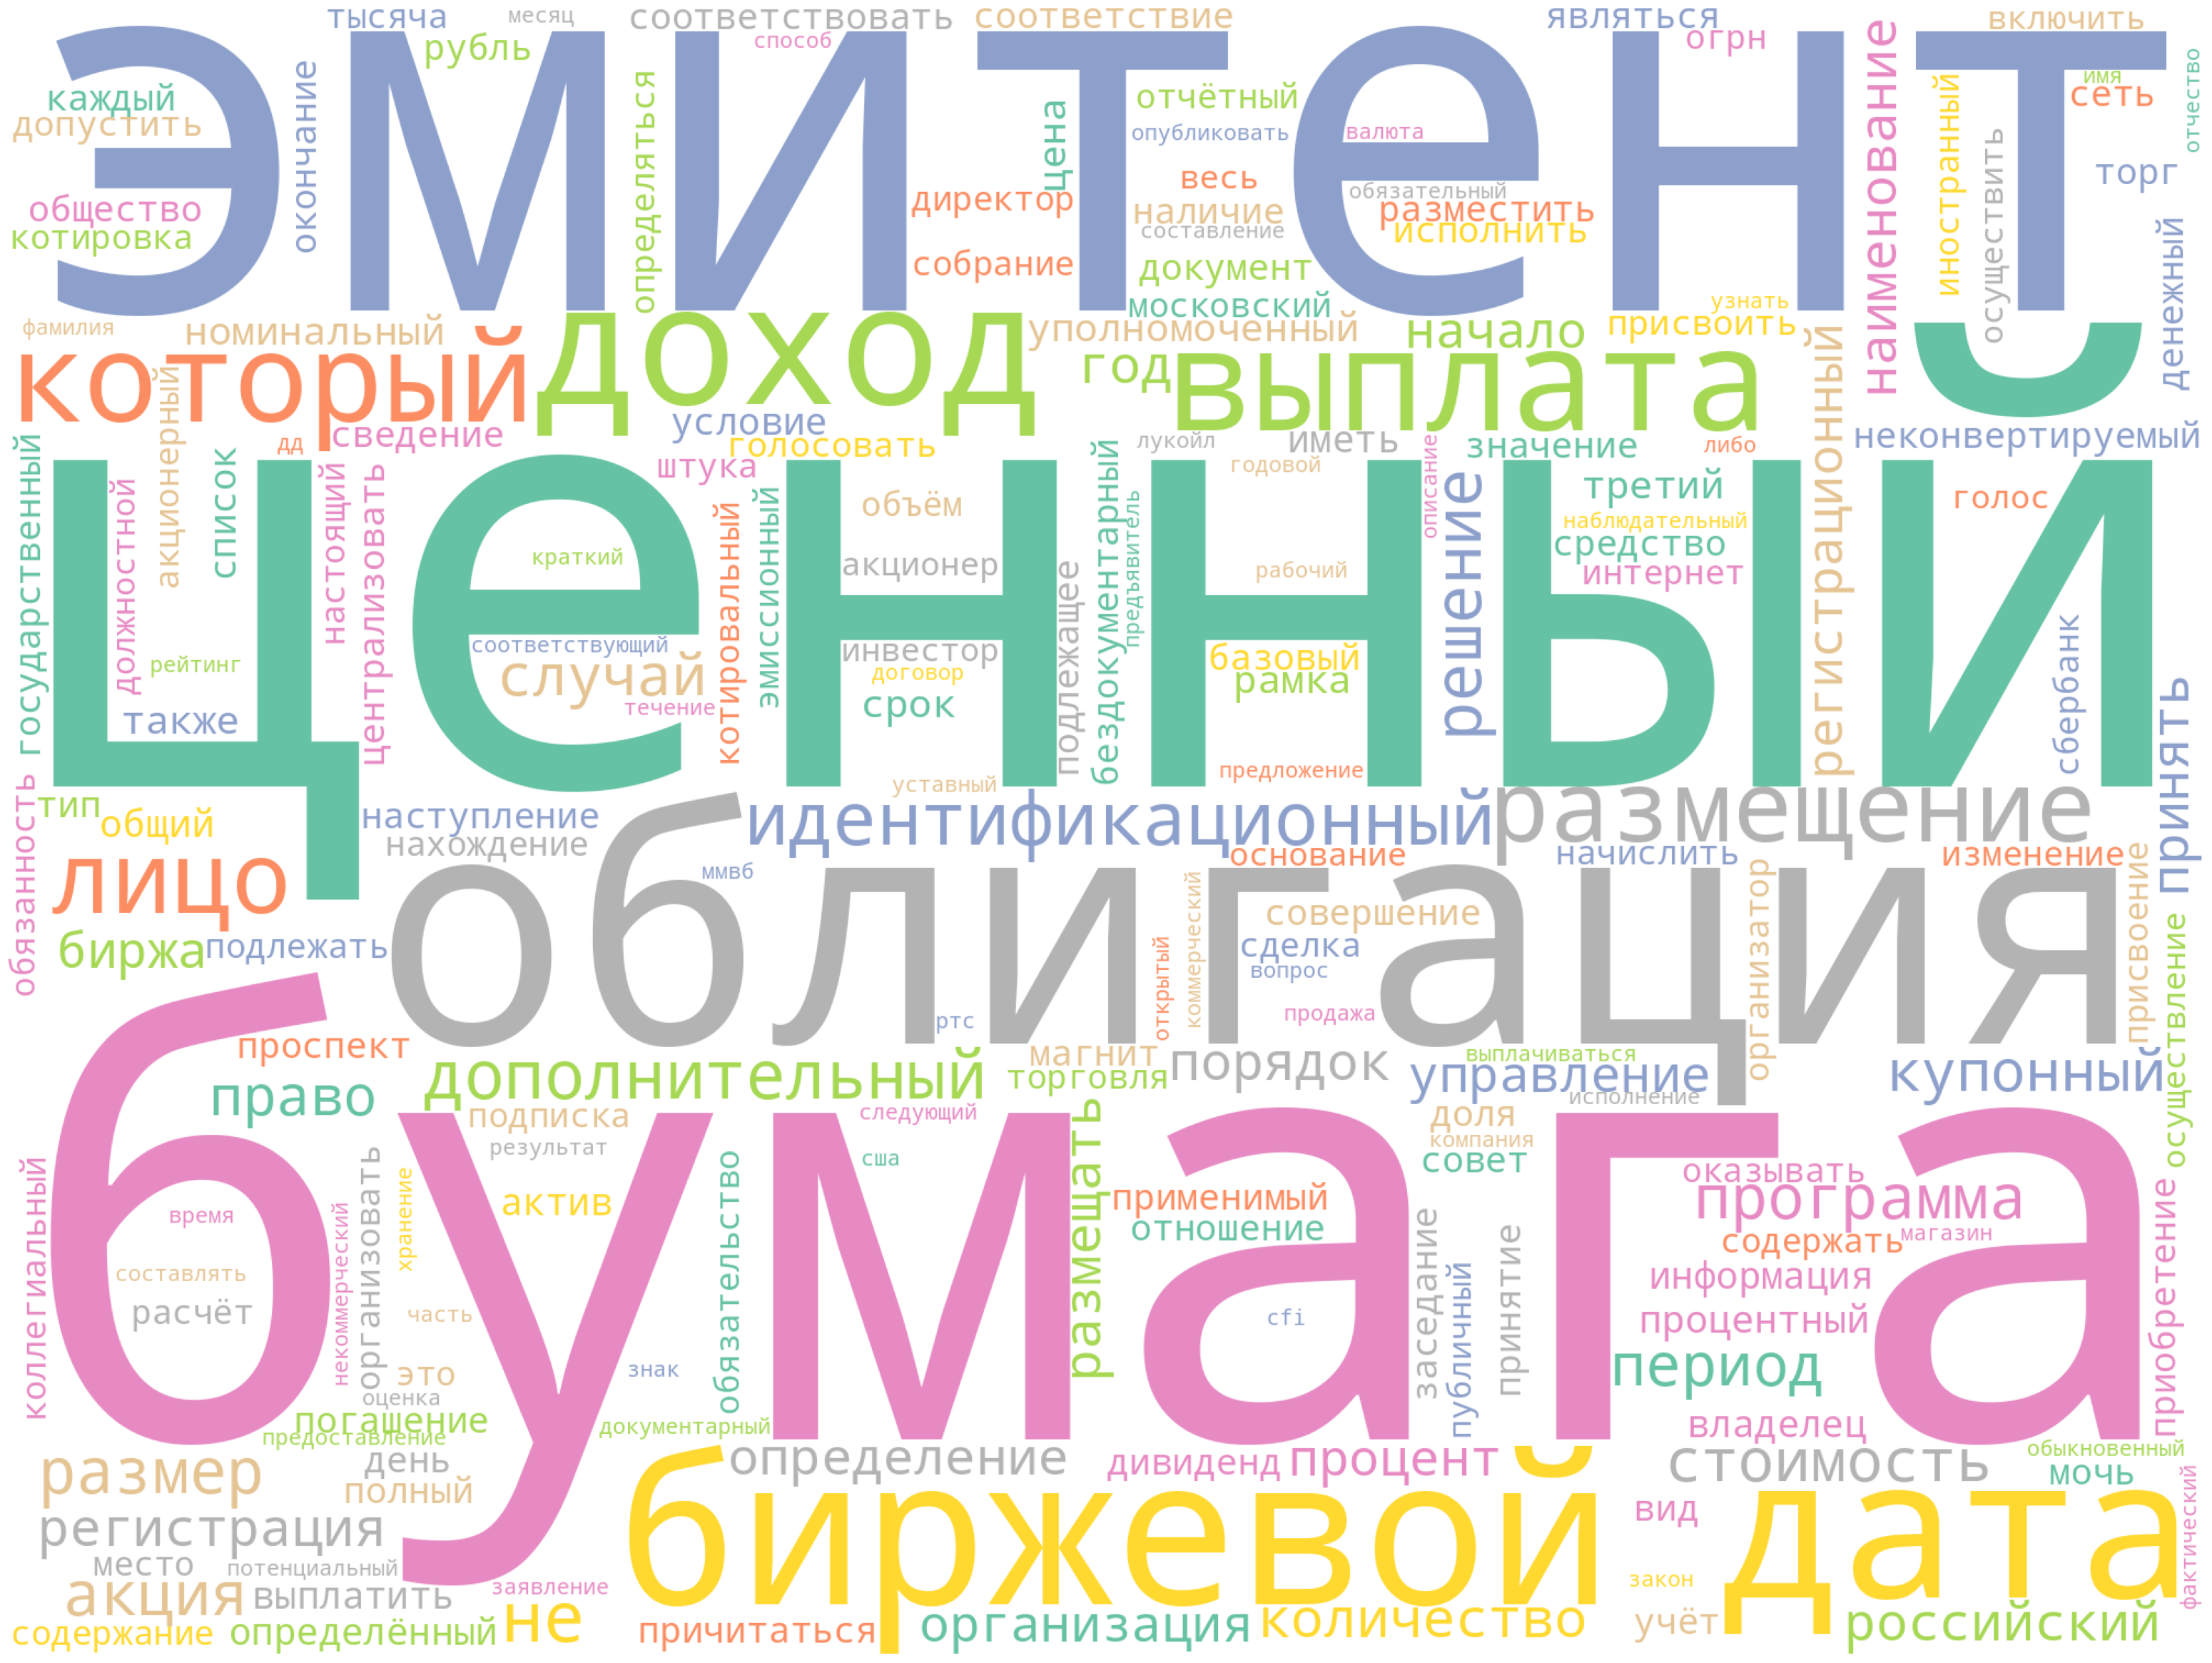

In [125]:
plot_cloud(wordcloud)

### Облако слов для копаний

In [ ]:
companies = ['sber', 'gazprom', 'lukoil', 'nlmk', 'magnit', 'positive-technologies']

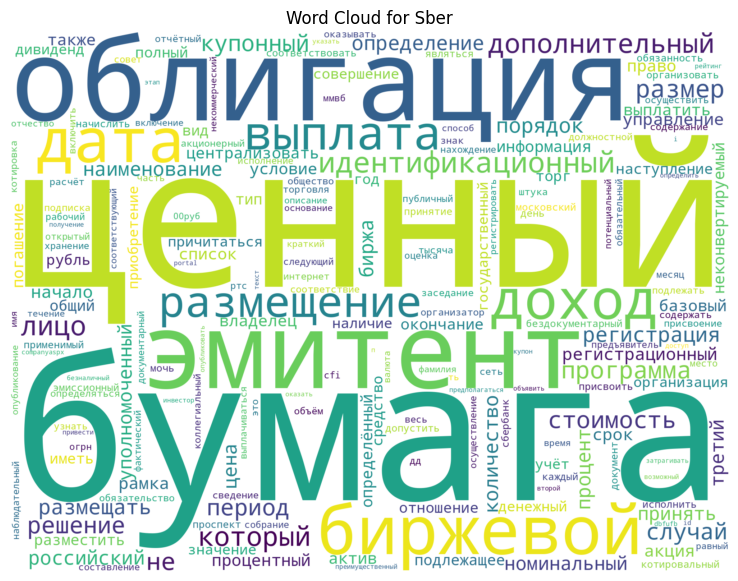

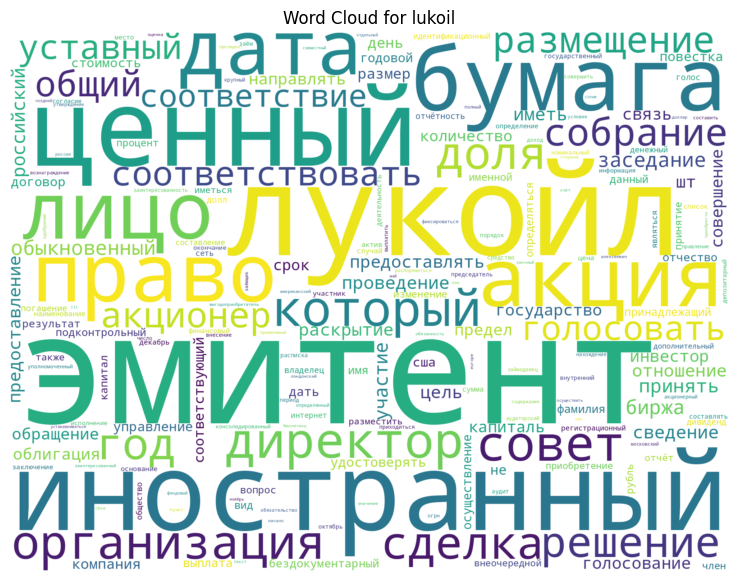

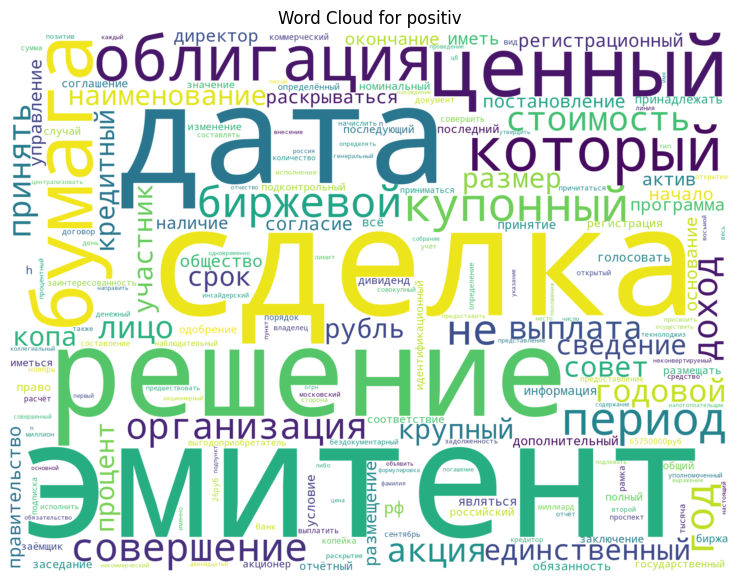

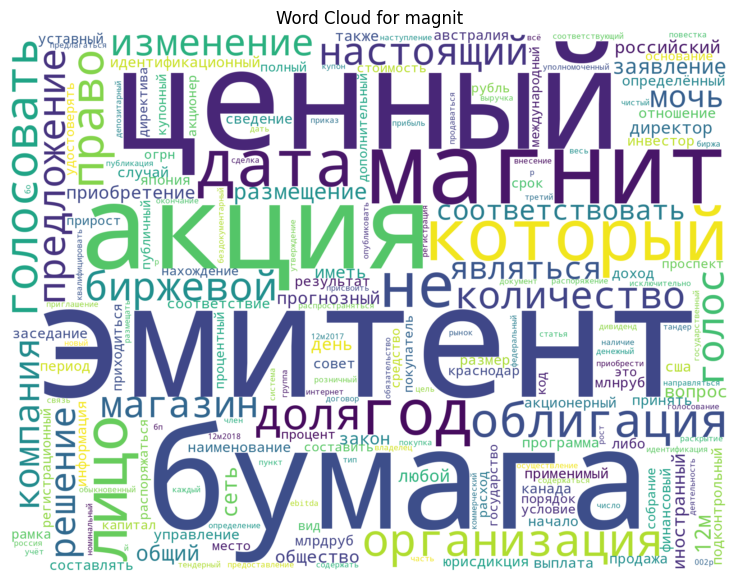

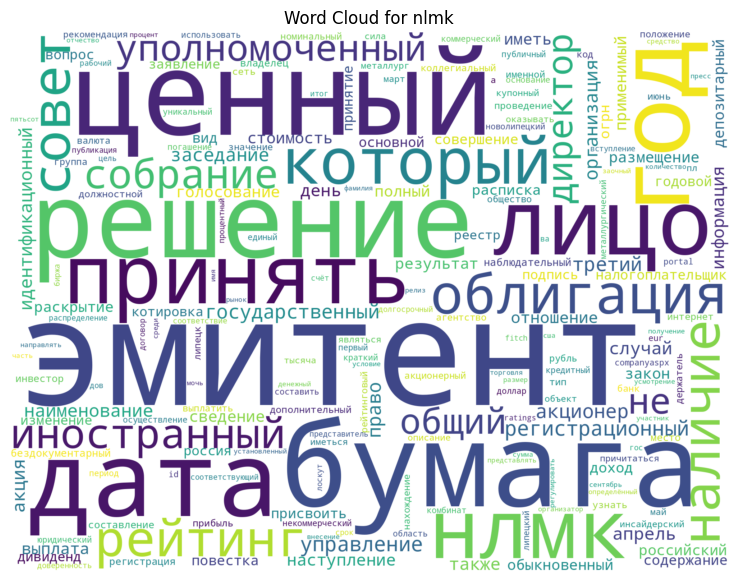

In [127]:
for company in companies:
    company_list = data[data['Id'].apply(lambda x: x[0]) == company[0]]['body_text_nostop']
    company_news = []
    [company_news.extend(t) for t in company_list]
    company_raw = " ".join(company_news)
    wordcloud = WordCloud(width = 2000,
                      height = 1500,
                      random_state=1,
                      background_color='white',
                      colormap='viridis_r',
                      collocations=False,
                     stopwords=stopword).generate(company_raw)
    plt.figure(figsize=(10, 7))
    plt.title(f"Word Cloud for {company}")  # Заголовок для графика
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Убираем оси

### Облако слов для существенных/несущественных новостей

In [128]:
text_companies = [data.iloc[x]['body_text_lemmatized'] for x in range(len(data)) ]

In [ ]:
from nltk.probability import FreqDist
uselless = data[data['1. Существенное']==0]
usefull = data[data['1. Существенное']==1]
cloud_of_words_useful = []
cloud_of_words_useless = []
for sublist in usefull['body_text_lemmatized']:
    for word in sublist:
        cloud_of_words_useful.append(word)
for sublist in uselless['body_text_lemmatized']:
    for word in sublist:
        cloud_of_words_useless.append(word)
freqsdist_usefull = FreqDist(cloud_of_words_useful)
freqsdist_useless= FreqDist(cloud_of_words_useless)

Text(0.5, 1.0, 'Облако слов для существенных новостей')

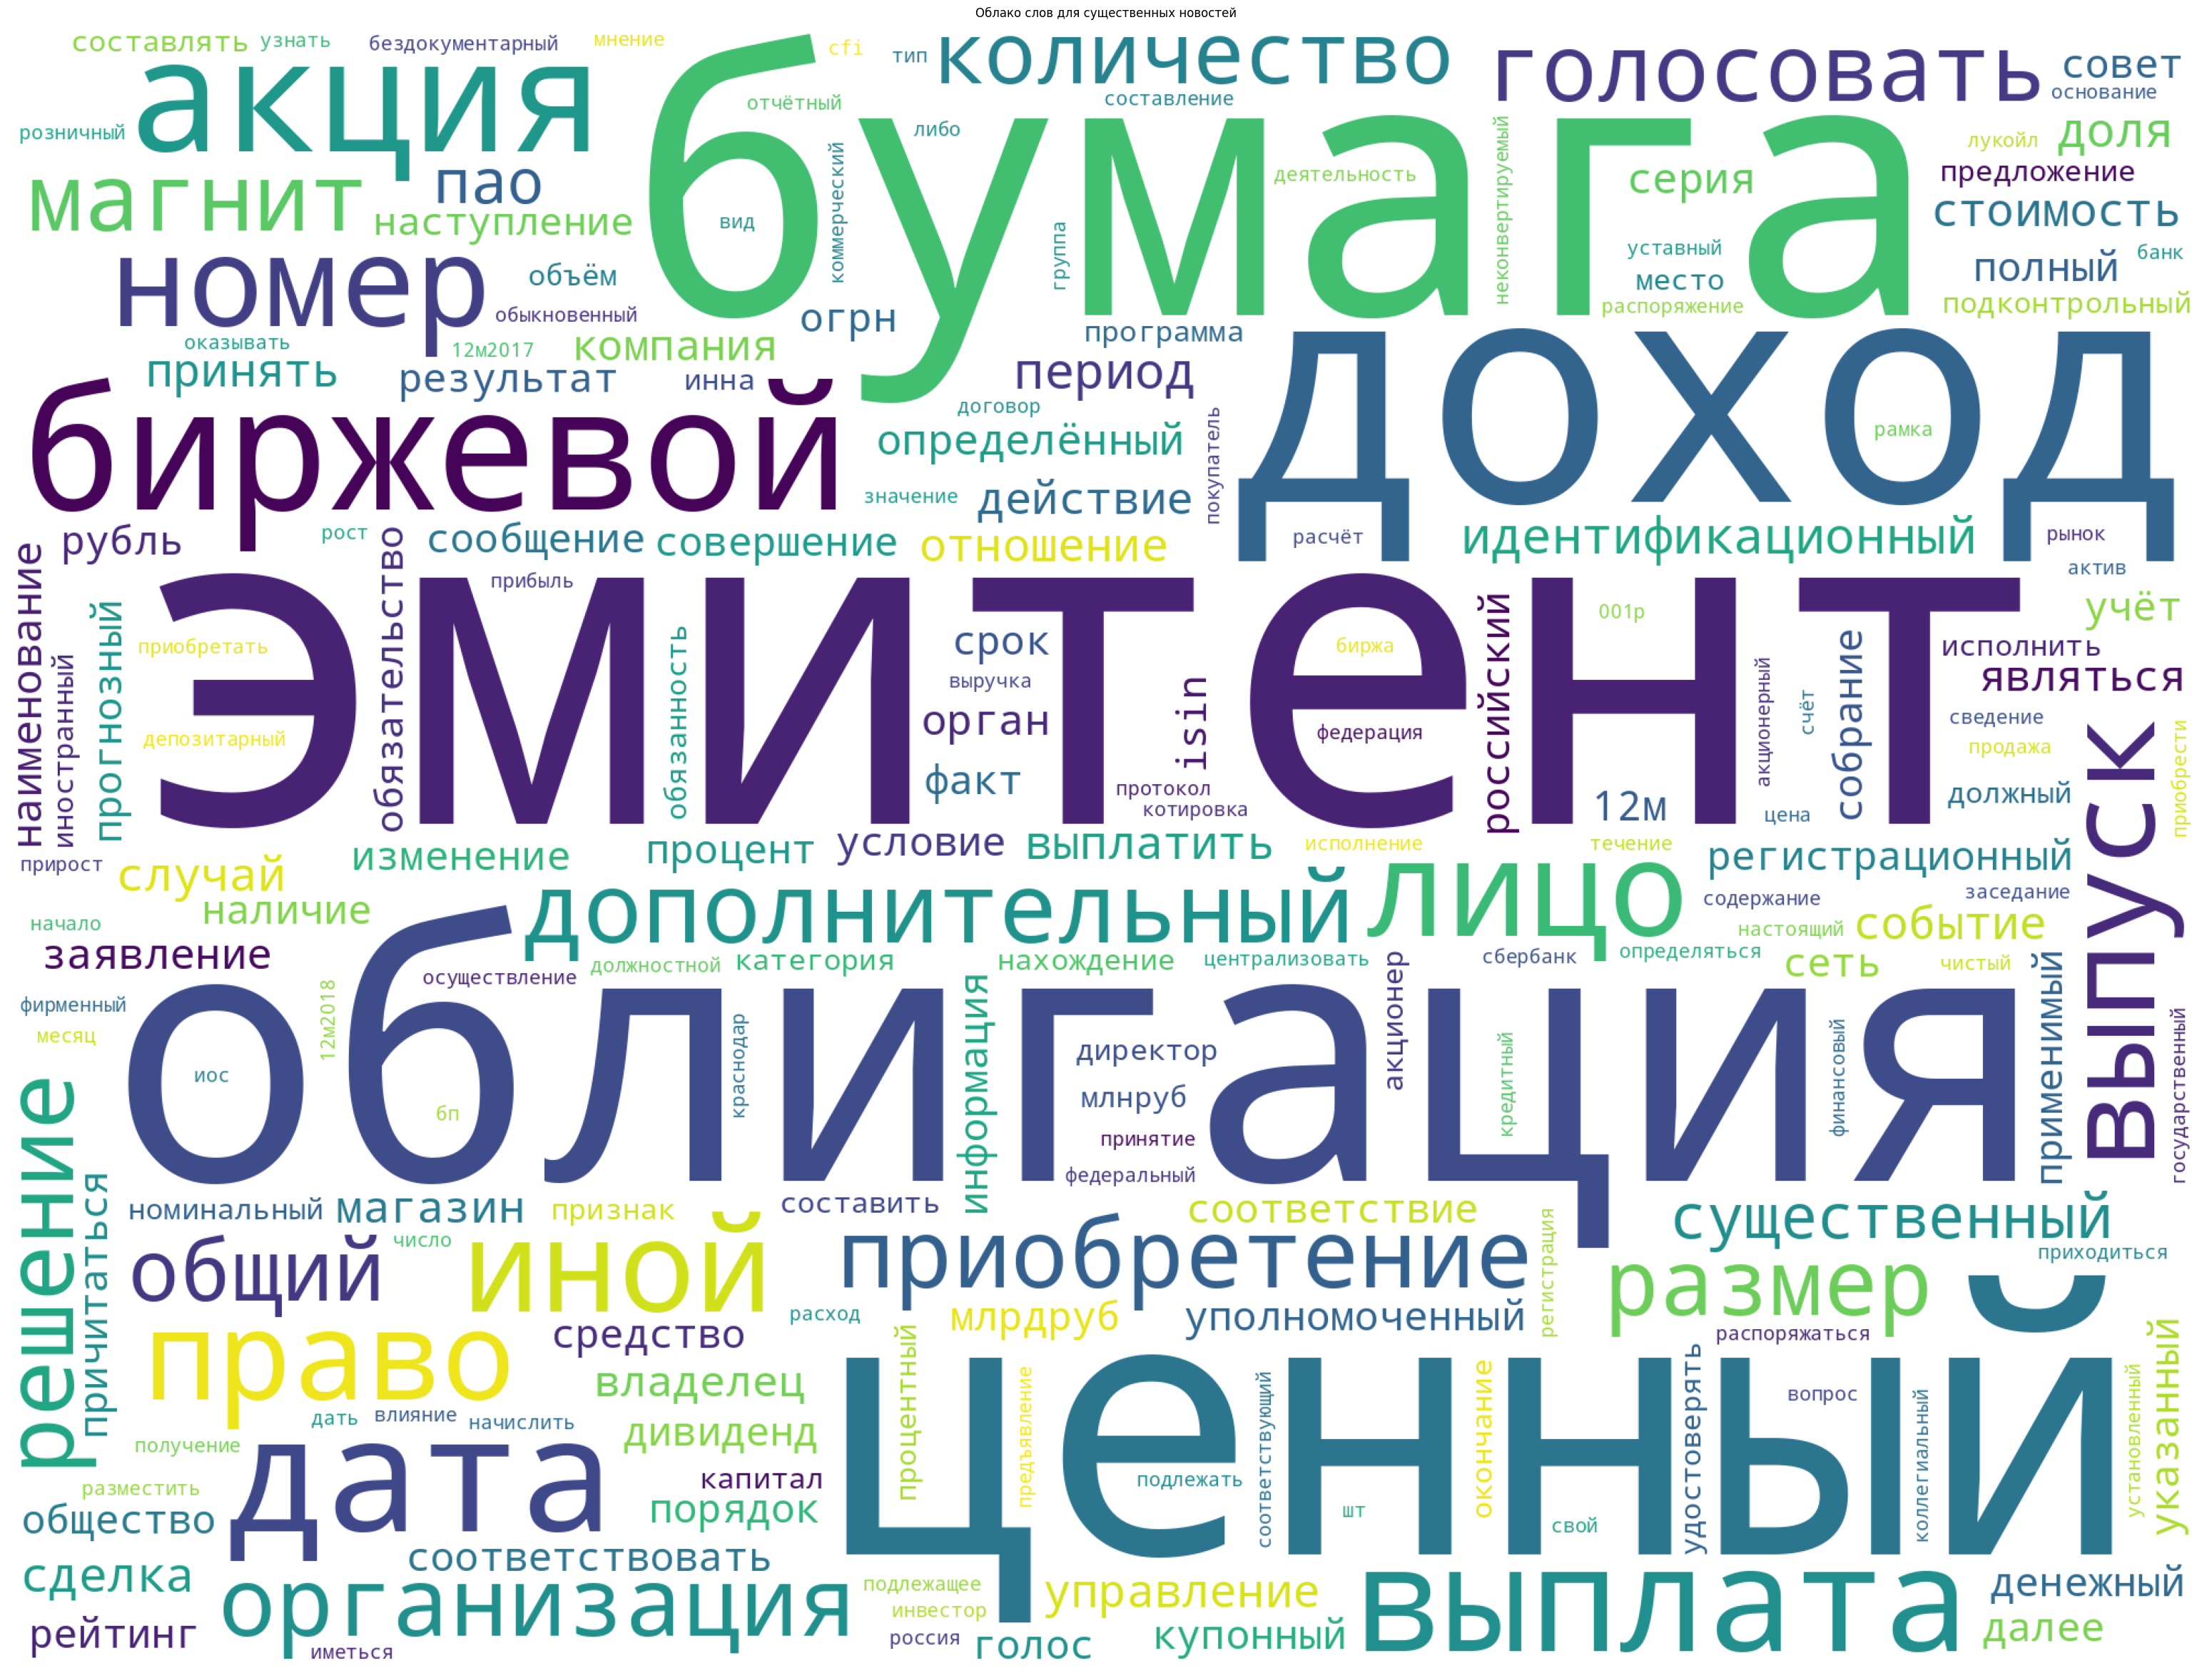

In [130]:
# Импортируем библиотеку для визуализации
import matplotlib.pyplot as plt
%matplotlib inline

# Функция для визуализации облака слов
def plot_cloud(wordcloud):
    # Устанавливаем размер картинки
    plt.figure(figsize=(40, 30))
    # Показать изображение
    plt.imshow(wordcloud)
    # Без подписей на осях
    plt.axis("off")
#облако слов для существенных новостей

from wordcloud import WordCloud
from stop_words import get_stop_words

# Записываем в переменную стоп-слова русского языка
STOPWORDS_RU = get_stop_words('russian')

# Генерируем облако слов
wordcloud = WordCloud(width = 2000,
                      height = 1500,
                      random_state=1,
                      background_color='white',
                      margin=20,
                      colormap='viridis',
                      collocations=False,
                      stopwords = STOPWORDS_RU).generate(" ".join(cloud_of_words_useful))

# Рисуем картинку
plot_cloud(wordcloud)
plt.title('Облако слов для существенных новостей')

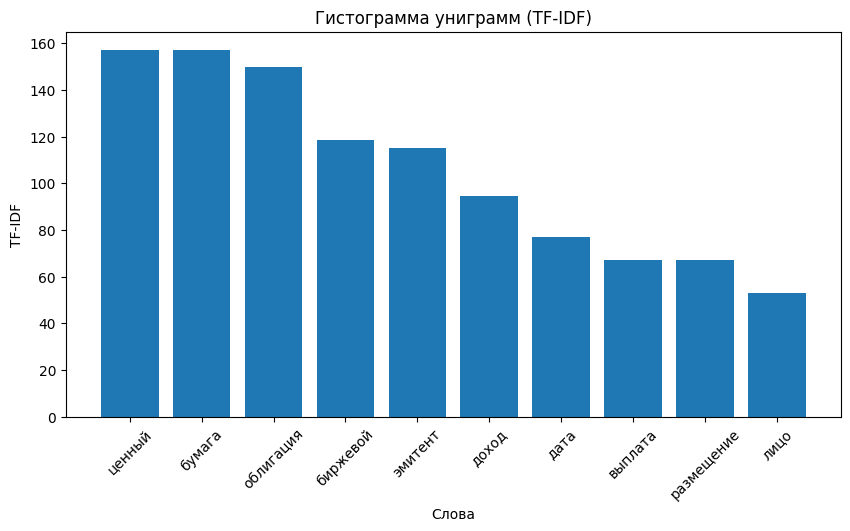

In [131]:
from sklearn.feature_extraction.text import TfidfVectorizer

data['body_text_nostop'] = data['body_text_nostop'].apply(lambda x: ' '.join(x) if isinstance(x, list) else str(x))
# Создаем объект TF-IDF для униграмм
vectorizer = TfidfVectorizer(ngram_range=(1, 1))  # Только униграммы
tfidf_matrix = vectorizer.fit_transform(data['body_text_nostop'])

# Получаем слова и их TF-IDF значения
feature_names = vectorizer.get_feature_names_out()
tfidf_values = tfidf_matrix.sum(axis=0).A1  # Суммируем значения TF-IDF по всем документам

# Создаем DataFrame
tfidf_df = pd.DataFrame({'word': feature_names, 'tfidf': tfidf_values}).sort_values(by='tfidf', ascending=False)

# Строим гистограмму
plt.figure(figsize=(10, 5))
plt.bar(tfidf_df['word'][:10], tfidf_df['tfidf'][:10])  # Топ-10 слов
plt.xlabel('Слова')
plt.ylabel('TF-IDF')
plt.title('Гистограмма униграмм (TF-IDF)')
plt.xticks(rotation=45)
plt.show()

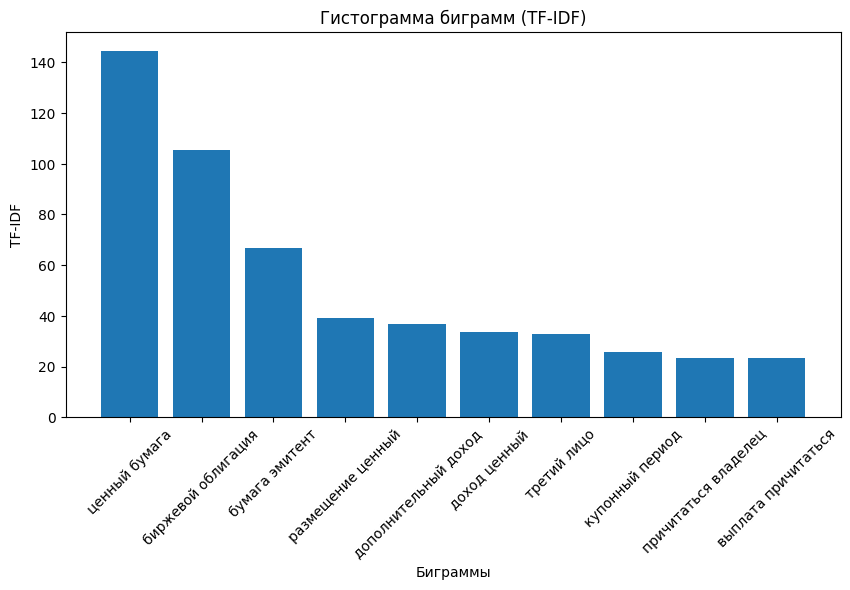

In [132]:
# Создаем объект TF-IDF для биграмм

vectorizer_bi = TfidfVectorizer(ngram_range=(2, 2))  # Только биграммы
tfidf_matrix_bi = vectorizer_bi.fit_transform(data['body_text_nostop'])
# Получаем биграммы и их TF-IDF значения
feature_names_bi = vectorizer_bi.get_feature_names_out()
tfidf_values_bi = tfidf_matrix_bi.sum(axis=0).A1

# Создаем DataFrame
tfidf_df_bi = pd.DataFrame({'bigram': feature_names_bi, 'tfidf': tfidf_values_bi}).sort_values(by='tfidf', ascending=False)

# Строим гистограмму биграмм
plt.figure(figsize=(10, 5))
plt.bar(tfidf_df_bi['bigram'][:10], tfidf_df_bi['tfidf'][:10])  # Топ-10 биграмм
plt.xlabel('Биграммы')
plt.ylabel('TF-IDF')
plt.title('Гистограмма биграмм (TF-IDF)')
plt.xticks(rotation=45)
plt.show()

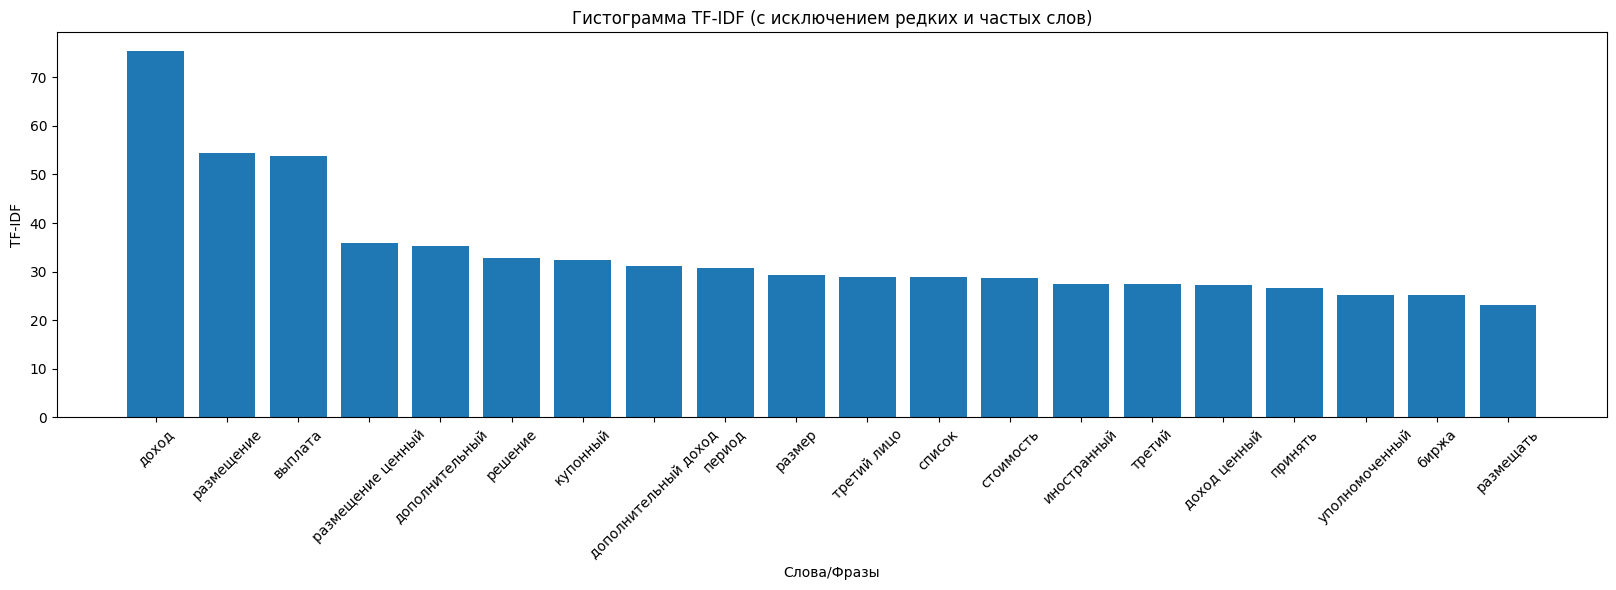

In [133]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Создаем TF-IDF векторизатор
vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.6)  # min_df=2 исключает редкие, max_df=0.8 убирает частые

# Преобразуем тексты
tfidf_matrix = vectorizer.fit_transform(data['body_text_nostop'])

# Получаем слова/фразы и их TF-IDF значения
feature_names = vectorizer.get_feature_names_out()
tfidf_values = tfidf_matrix.sum(axis=0).A1

# Создаем DataFrame
tfidf_df = pd.DataFrame({'word': feature_names, 'tfidf': tfidf_values}).sort_values(by='tfidf', ascending=False)

# Строим гистограмму топ-10
plt.figure(figsize=(20, 5))
plt.bar(tfidf_df['word'][:20], tfidf_df['tfidf'][:20])  # Топ-10 слов
plt.xlabel('Слова/Фразы')
plt.ylabel('TF-IDF')
plt.title('Гистограмма TF-IDF (с исключением редких и частых слов)')
plt.xticks(rotation=45)
plt.show()

### Финальный датасет

In [ ]:
final_test_data = data.drop(columns = ['Header', 'body_text', '1 разметчик', '2 разметчик', 'body_text_tokenised', 'body_text_lemmatized'])


In [ ]:
final_test_data.to_csv('test_data.csv', index=False, encoding='utf-8')